In [27]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [27]:
# import packages
import glob
import os.path as osp
import random
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
%matplotlib inline

import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
from torchvision import models, transforms

In [28]:
# setting random number seed.
torch.manual_seed(1234)
np.random.seed(1234)
random.seed(1234)

# preprocess class for each image
class ImageTransform():
    def __init__(self, size, mean, std):
        self.data_transform = {
            'train': transforms.Compose([
                # data augmentation
                transforms.RandomResizedCrop(size, scale=(0.5, 1.0)),
                transforms.RandomHorizontalFlip(),
                # convert to tensor for PyTorch
                transforms.ToTensor(),
                # color normalization
                transforms.Normalize(mean, std)
            ]),
            'val': transforms.Compose([
                transforms.CenterCrop(size),
                transforms.ToTensor(),
                transforms.Normalize(mean, std)
            ])
        }

    def __call__(self, img, phase='train'):

        return self.data_transform[phase](img)

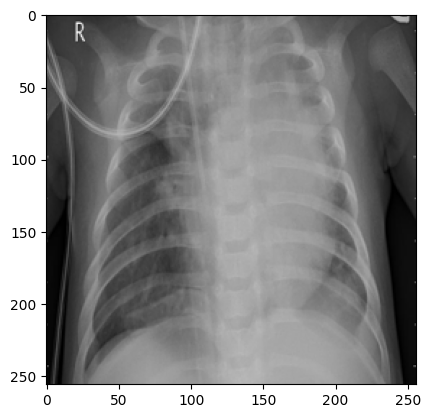

torch.Size([3, 256, 256])


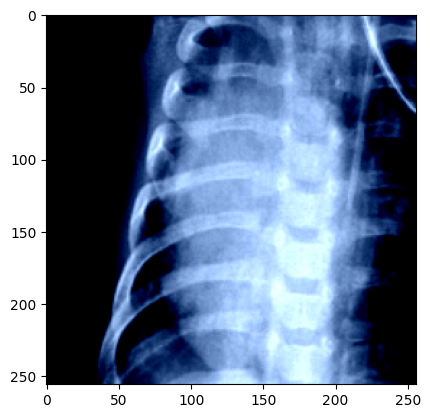

In [29]:
image_file_path = './chest_xray/test/PNEUMONIA/person100_bacteria_479.jpeg'

img_originalsize = Image.open(image_file_path) # [channel, ]
img = img_originalsize.resize((256, 256))
img = img.convert("L").convert("RGB")
plt.imshow(img)
plt.show()

# after preprocess
size = 256
mean = (0.485, 0.456, 0.406)
std = (0.229, 0.224, 0.225)
transform = ImageTransform(size, mean, std)
img_transformed = transform(img, phase="train")
print (img_transformed.shape)

# (color, height, width) -> (height, width, color), normalize colors in the range (0 - 1)
img_transformed = img_transformed.numpy().transpose((1, 2, 0))
img_transformed = np.clip(img_transformed, 0, 1)
plt.imshow(img_transformed)
plt.show()


In [30]:
import os.path as osp
import glob

# Making file path list
def make_datapath_list(phase="train"):
    rootpath = "chest_xray"
    target_path = osp.join(rootpath, phase, "**", "*.jpeg")
    path_list = glob.glob(target_path, recursive=True)
    return path_list

train_list = make_datapath_list(phase="train")
print(train_list)

val_list = make_datapath_list(phase="val")
print(len(val_list))

['chest_xray\\train\\NORMAL\\IM-0115-0001.jpeg', 'chest_xray\\train\\NORMAL\\IM-0117-0001.jpeg', 'chest_xray\\train\\NORMAL\\IM-0119-0001.jpeg', 'chest_xray\\train\\NORMAL\\IM-0122-0001.jpeg', 'chest_xray\\train\\NORMAL\\IM-0125-0001.jpeg', 'chest_xray\\train\\NORMAL\\IM-0127-0001.jpeg', 'chest_xray\\train\\NORMAL\\IM-0128-0001.jpeg', 'chest_xray\\train\\NORMAL\\IM-0129-0001.jpeg', 'chest_xray\\train\\NORMAL\\IM-0131-0001.jpeg', 'chest_xray\\train\\NORMAL\\IM-0133-0001.jpeg', 'chest_xray\\train\\NORMAL\\IM-0135-0001.jpeg', 'chest_xray\\train\\NORMAL\\IM-0137-0001.jpeg', 'chest_xray\\train\\NORMAL\\IM-0140-0001.jpeg', 'chest_xray\\train\\NORMAL\\IM-0141-0001.jpeg', 'chest_xray\\train\\NORMAL\\IM-0143-0001.jpeg', 'chest_xray\\train\\NORMAL\\IM-0145-0001.jpeg', 'chest_xray\\train\\NORMAL\\IM-0147-0001.jpeg', 'chest_xray\\train\\NORMAL\\IM-0149-0001.jpeg', 'chest_xray\\train\\NORMAL\\IM-0151-0001.jpeg', 'chest_xray\\train\\NORMAL\\IM-0152-0001.jpeg', 'chest_xray\\train\\NORMAL\\IM-0154-000

In [ ]:
class lungDataset(data.Dataset):

    def __init__(self, file_list, transform=None, phase='train'):
        self.file_list = file_list
        self.transform = transform
        self.phase = phase

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, index):

        img_path = self.file_list[index]
        img_originalsize = Image.open(img_path)
        img = img_originalsize.resize((256, 256))
        img = img.convert("L").convert("RGB")
        img_transformed = self.transform(img, self.phase)
        label = img_path.split('\\')[-2]
        if label == "NORMAL":
            label = 0
        elif label == "PNEUMONIA":
            label = 1

        return img_transformed, label

train_dataset = lungDataset(file_list=train_list, transform=ImageTransform(size, mean, std), phase='train')
val_dataset = lungDataset(file_list=val_list, transform=ImageTransform(size, mean, std), phase='val')

In [33]:
batch_size = 32

train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
dataloaders_dict = {"train": train_dataloader, "val": val_dataloader}

In [34]:
use_pretrained = True
net = models.vgg16(pretrained=use_pretrained)

# Replace output layer for 2 class classifier, 'NORMAL' and 'PNEUMONIA'.
net.classifier[6] = nn.Linear(in_features=4096, out_features=2)
net.train()

c:\Users\a\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\a\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [35]:
criterion = nn.CrossEntropyLoss()
params_to_update_1 = []
params_to_update_2 = []
params_to_update_3 = []

update_param_names_1 = ["features"]
update_param_names_2 = ["classifier.0.weight", "classifier.0.bias", "classifier.3.weight", "classifier.3.bias"]
update_param_names_3 = ["classifier.6.weight", "classifier.6.bias"]

for name, param in net.named_parameters():
    if update_param_names_1[0] in name:
        param.requires_grad = True
        params_to_update_1.append(param)
        # print("params_to_update_1:", name)

    elif name in update_param_names_2:
        param.requires_grad = True
        params_to_update_2.append(param)
        #print("params_to_update_2:", name)

    elif name in update_param_names_3:
        param.requires_grad = True
        params_to_update_3.append(param)
        #print("params_to_update_3:", name)

    else:
        param.requires_grad = False
        #print("no learning", name)

# Set learning rates
optimizer = optim.SGD([
    {'params': params_to_update_1, 'lr': 1e-4},
    {'params': params_to_update_2, 'lr': 5e-4},
    {'params': params_to_update_3, 'lr': 1e-3}
], momentum=0.9)


In [36]:
# training function
def train_model(net, dataloaders_dict, criterion, optimizer, num_epochs):

    accuracy_list = []
    loss_list = []

    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    print("using device：", device)
    net.to(device)
    torch.backends.cudnn.benchmark = True

    # epoch loop
    for epoch in range(num_epochs):
        print('Epoch {}/{}'.format(epoch+1, num_epochs))
        print('-------------')

        for phase in ['train', 'val']:
            if phase == 'train':
                net.train()
            else:
                net.eval()

            epoch_loss = 0.0
            epoch_corrects = 0

            for i, (inputs, labels) in enumerate(dataloaders_dict[phase]):

                print (f'Iteration: ', i)
                print (labels)

                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()
                with torch.set_grad_enabled(phase == 'train'):
                    # Forward pass
                    outputs = net(inputs)
                    loss = criterion(outputs, labels)  # Calcurate loss
                    _, preds = torch.max(outputs, 1)  # Prediction

                    # Back propagtion
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                    # update loss summation
                    epoch_loss += loss.item() * inputs.size(0)
                    # update correct prediction summation
                    epoch_corrects += torch.sum(preds == labels.data)

            # loss and accuracy for each epoch loop
            epoch_loss = epoch_loss / len(dataloaders_dict[phase].dataset)
            epoch_acc = epoch_corrects.double() / len(dataloaders_dict[phase].dataset)

            print('{} Loss: {:.4f} Acc: {:.4f}'.format(phase, epoch_loss, epoch_acc))

            if phase == 'val':
                accuracy_list.append(epoch_acc.item())
                loss_list.append(epoch_loss)

    return accuracy_list, loss_list


In [37]:
# start training
num_epochs=10
accuracy_list, loss_list = train_model(net, dataloaders_dict, criterion, optimizer, num_epochs=num_epochs)

using device： cpu
Epoch 1/10
-------------
chest_xray\train\PNEUMONIA\person724_bacteria_2626.jpeg
PNEUMONIA
chest_xray\train\PNEUMONIA\person23_bacteria_93.jpeg
PNEUMONIA
chest_xray\train\PNEUMONIA\person1413_bacteria_3620.jpeg
PNEUMONIA
chest_xray\train\NORMAL\IM-0314-0001.jpeg
NORMAL
chest_xray\train\NORMAL\NORMAL2-IM-0890-0001.jpeg
NORMAL
chest_xray\train\PNEUMONIA\person655_bacteria_2547.jpeg
PNEUMONIA
chest_xray\train\NORMAL\NORMAL2-IM-0439-0001.jpeg
NORMAL
chest_xray\train\PNEUMONIA\person1761_bacteria_4603.jpeg
PNEUMONIA
chest_xray\train\PNEUMONIA\person1376_virus_2367.jpeg
PNEUMONIA
chest_xray\train\PNEUMONIA\person366_virus_746.jpeg
PNEUMONIA
chest_xray\train\PNEUMONIA\person1160_virus_1947.jpeg
PNEUMONIA
chest_xray\train\PNEUMONIA\person371_bacteria_1695.jpeg
PNEUMONIA
chest_xray\train\PNEUMONIA\person88_virus_166.jpeg
PNEUMONIA
chest_xray\train\PNEUMONIA\person577_virus_1121.jpeg
PNEUMONIA
chest_xray\train\NORMAL\NORMAL2-IM-0869-0001.jpeg
NORMAL
chest_xray\train\NORMAL\IM-0

KeyboardInterrupt: 

In [25]:
# To save trained model
save_path = './weights_fine_tuning.pth'
torch.save(net.state_dict(), save_path)


ValueError: x and y must have same first dimension, but have shapes (10,) and (3,)

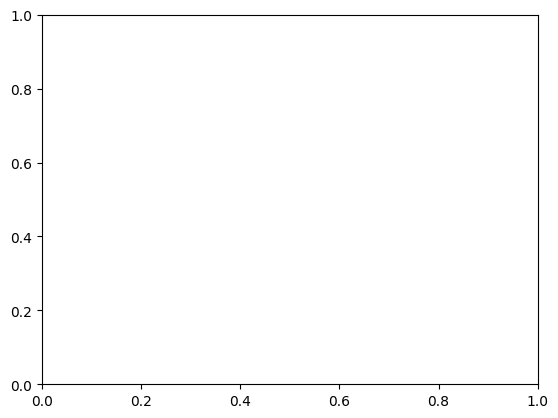

In [26]:
epoch_num = list(range(10))
fig, ax = plt.subplots(facecolor="w")
ax.plot(epoch_num, accuracy_list, label="accuracy")
ax.plot(epoch_num, loss_list, label="loss")
plt.xticks(epoch_num)
ax.legend()
plt.show()